# Week 10: AI & Modelling

In this practical, we will build a simple species distribution modelling (SDM) workflow.
We will start from point observations of species presence, link those observations to environmental covariates from raster maps, and then fit a few baseline SDM models.

By the end, you should be able to:

- extract environmental covariates from geospatial rasters;
- visualise ecological niches in environmental space;
- train and evaluate simple species distribution models.

## 1. Setup

First, let's download the data.

In [1]:
%%bash

gdown 1cEhhjNYWz3CvJ-wQmkBf6wuUyXaKT9ug
unzip bios0032_ai_modelling_data.zip
pip install geodatasets

Archive:  bios0032_ai_modelling_data.zip
   creating: data/
  inflating: data/observations.csv   
   creating: data/rasters/
  inflating: data/rasters/wc2.1_5m_bio_5.tif  
  inflating: data/rasters/wc2.1_5m_bio_7.tif  
  inflating: data/rasters/wc2.1_5m_bio_12.tif  
  inflating: data/rasters/wc2.1_5m_bio_10.tif  
  inflating: data/rasters/wc2.1_5m_bio_16.tif  
  inflating: data/rasters/wc2.1_5m_bio_4.tif  
  inflating: data/rasters/wc2.1_5m_elev.tif  
  inflating: data/rasters/wc2.1_5m_bio_15.tif  
  inflating: data/rasters/wc2.1_5m_bio_9.tif  
  inflating: data/rasters/wc2.1_5m_bio_14.tif  
  inflating: data/rasters/wc2.1_5m_bio_11.tif  
  inflating: data/rasters/wc2.1_5m_bio_18.tif  
  inflating: data/rasters/wc2.1_5m_bio_8.tif  
  inflating: data/rasters/wc2.1_5m_bio_13.tif  
  inflating: data/rasters/wc2.1_5m_bio_19.tif  
  inflating: data/rasters/wc2.1_5m_bio_3.tif  
  inflating: data/rasters/wc2.1_5m_bio_6.tif  
  inflating: data/rasters/wc2.1_5m_bio_1.tif  
  inflating: data/ras

Downloading...
From (original): https://drive.google.com/uc?id=1cEhhjNYWz3CvJ-wQmkBf6wuUyXaKT9ug
From (redirected): https://drive.google.com/uc?id=1cEhhjNYWz3CvJ-wQmkBf6wuUyXaKT9ug&confirm=t&uuid=f1c4a23d-6edb-4f95-bb14-73d93ea5cb98
To: /content/bios0032_ai_modelling_data.zip
100%|██████████| 185M/185M [00:01<00:00, 116MB/s] 


Then define the location of the local data folder.

In [2]:
from pathlib import Path

data_dir = Path("data")

Now we can load the table of observations.

In [3]:
import pandas as pd

observations = pd.read_csv(data_dir / "observations.csv")

observations.head()

,lon,lat,species,id
0,-109.900000,49.583300,Lasiurus_cinereus,1414132141
1,-98.081754,19.694223,Lasiurus_cinereus,1418533465
2,-105.994193,25.955892,Lasiurus_cinereus,1422088335
3,-99.555278,18.591944,Lasiurus_cinereus,1418249950
4,-104.017754,25.278463,Lasiurus_cinereus,1422086748


Each row is one observation event with longitude, latitude, and species.
Let's list the species in the dataset, then count how many records we have for each one.

In [4]:
species_list = sorted(observations["species"].unique())
species_list

['Ammospermophilus_leucurus',
 'Canis_lupus',
 'Clethrionomys_gapperi',
 'Dipodomys_ordii',
 'Lasiurus_cinereus',
 'Marmota_flaviventris',
 'Microtus_pennsylvanicus',
 'Rangifer_tarandus',
 'Scalopus_aquaticus',
 'Tamiasciurus_douglasii']

In [5]:
obs_count_by_species = observations["species"].value_counts()

obs_count_by_species

,count
species,
Rangifer_tarandus,776
Microtus_pennsylvanicus,774
Clethrionomys_gapperi,726
Marmota_flaviventris,675
Scalopus_aquaticus,595
Dipodomys_ordii,585
Tamiasciurus_douglasii,573
Canis_lupus,565
Lasiurus_cinereus,558


#### 🖌️ _Species ranges_

For a selection of species of your choice, search online for species range maps.
Then go to each species page on iNaturalist and open the **Map** tab to compare:

- the expected/estimated range,
- the observed records on iNaturalist.

Do the broad geographic patterns in iNaturalist look consistent with what you see in this dataset?
Note any clear mismatches or sampling gaps.

## 2. Explore the observations

Let's visualise where records are located across North America.

In [6]:
import geodatasets
import geopandas as gpd

world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

(14.541996, 79.980922)

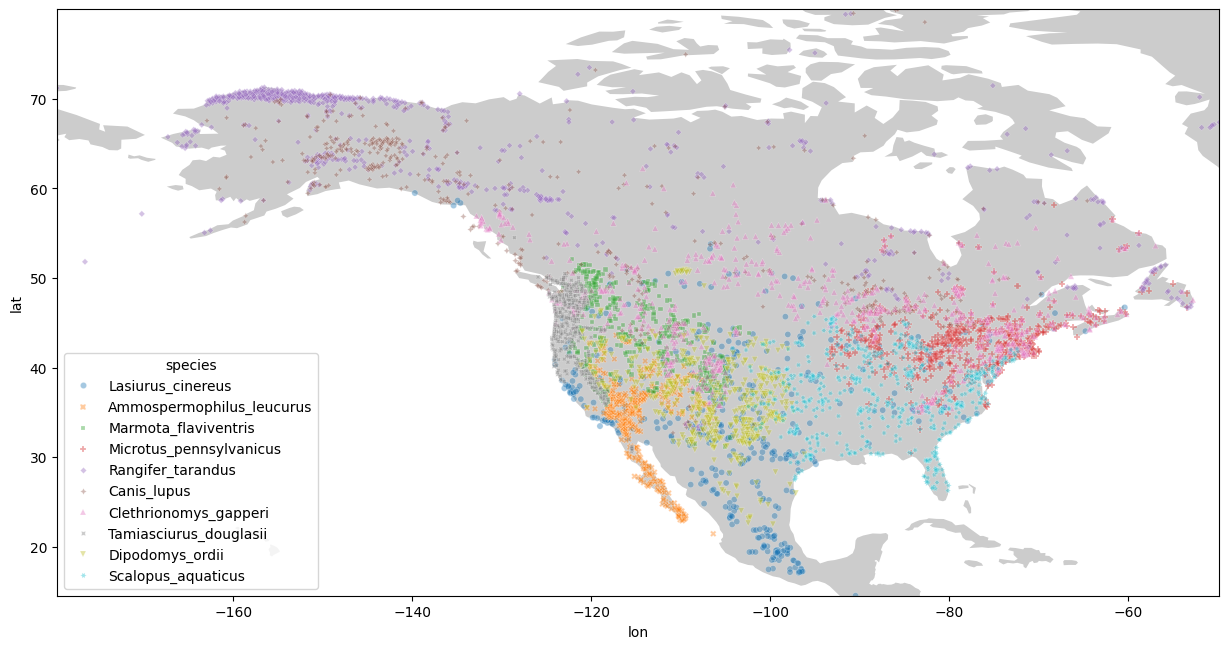

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(15, 10))
world.plot(ax=ax, alpha=0.4, color="grey")
sns.scatterplot(
    data=observations,
    ax=ax,
    x="lon",
    y="lat",
    hue="species",
    style="species",
    s=20,
    alpha=0.4,
)
ax.set_xlim(observations.lon.min(), observations.lon.max())
ax.set_ylim(observations.lat.min(), observations.lat.max())

Some coordinates contain observations from multiple species.
For modelling, it is useful to define unique sampling sites.

In [8]:
locations = (
    observations[["lon", "lat"]]
    .drop_duplicates()
    .reset_index()
    .rename(columns={"index": "site_id"})
)

locations

,site_id,lon,lat
0,0,-109.900000,49.583300
1,1,-98.081754,19.694223
2,2,-105.994193,25.955892
3,3,-99.555278,18.591944
4,4,-104.017754,25.278463
...,...,...,...
6242,6328,-95.170098,38.999518
6243,6329,-100.527779,39.818329
6244,6330,-97.051437,33.553883
6245,6332,-92.372013,34.595356


Now add the `site_id` back onto each observation record.

In [9]:
observations = pd.merge(
    left=observations,
    right=locations,
    left_on=["lon", "lat"],
    right_on=["lon", "lat"],
    how="left",
)

With site IDs in place, we can build an occurrence matrix (sites x species), where each value is `True` if the species was recorded at that site.
For any focal species, we can read down one column to get a presence/absence vector across sites.

In [10]:
occ_matrix = ~observations.pivot(
    index="site_id", columns="species", values="species"
).isna()

occ_matrix

species,Ammospermophilus_leucurus,Canis_lupus,Clethrionomys_gapperi,Dipodomys_ordii,Lasiurus_cinereus,Marmota_flaviventris,Microtus_pennsylvanicus,Rangifer_tarandus,Scalopus_aquaticus,Tamiasciurus_douglasii
site_id,,,,,,,,,,
0,False,False,False,False,True,False,False,False,False,False
1,False,False,False,False,True,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
6328,False,False,False,False,False,False,False,False,True,False
6329,False,False,False,False,False,False,False,False,True,False
6330,False,False,False,False,False,False,False,False,True,False


#### 🖌️ _Co-occurrence and absence_

Count the number of sites where more than one species is recorded.
Is this a realistic estimate of how often species truly co-occur?

Now think about sites where a species is not detected.
Can we be sure that it is absent?

- Why might a non-detection represent a true absence?
- Why might a non-detection still occur even when the species is present?

## 3. Environmental covariates

We will use [WorldClim](https://www.worldclim.org/data/bioclim.html) bioclimatic variables and elevation at 5 arc-minute resolution.
These are common baseline covariates in SDM studies.

From an ecological perspective, these predictors act as broad proxies for:

- **energy constraints** (temperature-related BIO variables),
- **water constraints** (precipitation-related BIO variables),
- **topographic context** (elevation).

They do not directly capture biotic interactions, disturbance history, or microhabitat, but they are often good first-order predictors at continental scales.

- BIO1 = Annual Mean Temperature
- BIO2 = Mean Diurnal Range (Mean of monthly (max temp - min temp))
- BIO3 = Isothermality (BIO2/BIO7) (×100)
- BIO4 = Temperature Seasonality (standard deviation ×100)
- BIO5 = Max Temperature of Warmest Month
- BIO6 = Min Temperature of Coldest Month
- BIO7 = Temperature Annual Range (BIO5-BIO6)
- BIO8 = Mean Temperature of Wettest Quarter
- BIO9 = Mean Temperature of Driest Quarter
- BIO10 = Mean Temperature of Warmest Quarter
- BIO11 = Mean Temperature of Coldest Quarter
- BIO12 = Annual Precipitation
- BIO13 = Precipitation of Wettest Month
- BIO14 = Precipitation of Driest Month
- BIO15 = Precipitation Seasonality (Coefficient of Variation)
- BIO16 = Precipitation of Wettest Quarter
- BIO17 = Precipitation of Driest Quarter
- BIO18 = Precipitation of Warmest Quarter
- BIO19 = Precipitation of Coldest Quarter
- ELEV = Meters above sea level

At this point, it is also worth noting that many BIO variables are correlated.
Later, this matters for interpretation because multiple predictors may encode similar climate gradients.

Let's start by listing all associated files.
Each BIO variable is stored as a TIFF raster, which (as in the Remote Sensing week) is like an image with spatial referencing.

In [11]:
raster_dir = data_dir / "rasters"
prefix = "wc2.1_5m"

rasters = {
    "BIO01": raster_dir / f"{prefix}_bio_1.tif",
    "BIO02": raster_dir / f"{prefix}_bio_2.tif",
    "BIO03": raster_dir / f"{prefix}_bio_3.tif",
    "BIO04": raster_dir / f"{prefix}_bio_4.tif",
    "BIO05": raster_dir / f"{prefix}_bio_5.tif",
    "BIO06": raster_dir / f"{prefix}_bio_6.tif",
    "BIO07": raster_dir / f"{prefix}_bio_7.tif",
    "BIO08": raster_dir / f"{prefix}_bio_8.tif",
    "BIO09": raster_dir / f"{prefix}_bio_9.tif",
    "BIO10": raster_dir / f"{prefix}_bio_10.tif",
    "BIO11": raster_dir / f"{prefix}_bio_11.tif",
    "BIO12": raster_dir / f"{prefix}_bio_12.tif",
    "BIO13": raster_dir / f"{prefix}_bio_13.tif",
    "BIO14": raster_dir / f"{prefix}_bio_14.tif",
    "BIO15": raster_dir / f"{prefix}_bio_15.tif",
    "BIO16": raster_dir / f"{prefix}_bio_16.tif",
    "BIO17": raster_dir / f"{prefix}_bio_17.tif",
    "BIO18": raster_dir / f"{prefix}_bio_18.tif",
    "BIO19": raster_dir / f"{prefix}_bio_19.tif",
    "ELEV": raster_dir / f"{prefix}_elev.tif",
}

Let's inspect one raster first: BIO01 (annual mean temperature).
This is a quick check that the files loaded correctly and that masking works as expected.

/usr/local/lib/python3.12/dist-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


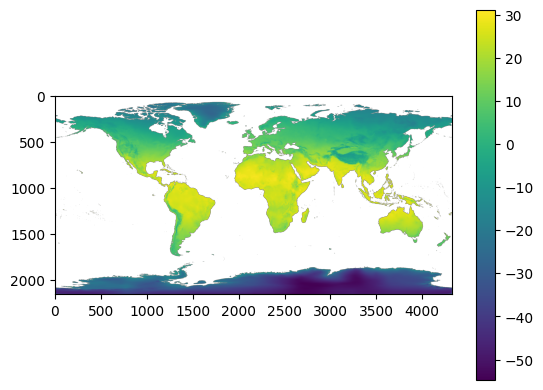

In [12]:
import numpy as np
import rasterio

# Let's use rasterio to open the raster file
covariate = "BIO01"
src = rasterio.open(rasters[covariate])

# Then we can read the values
array = src.read(1)

# But some values are not valid, for example those over the oceans
# The map contains info about which pixels contain valid info
# This is called a mask
mask = src.read_masks(1)

# We can tell numpy which pixels of the full map need to be masked
array = np.ma.masked_where(~mask, array)

# And plot it
plt.imshow(array)
plt.colorbar()

#### 🖌️ _BIO13 and BIO16 correlation_

Plot `BIO13` (precipitation of wettest month) and `BIO16` (precipitation of wettest quarter) next to each other.
Do they look similar?

Can you produce a map of places where the difference between them is large?

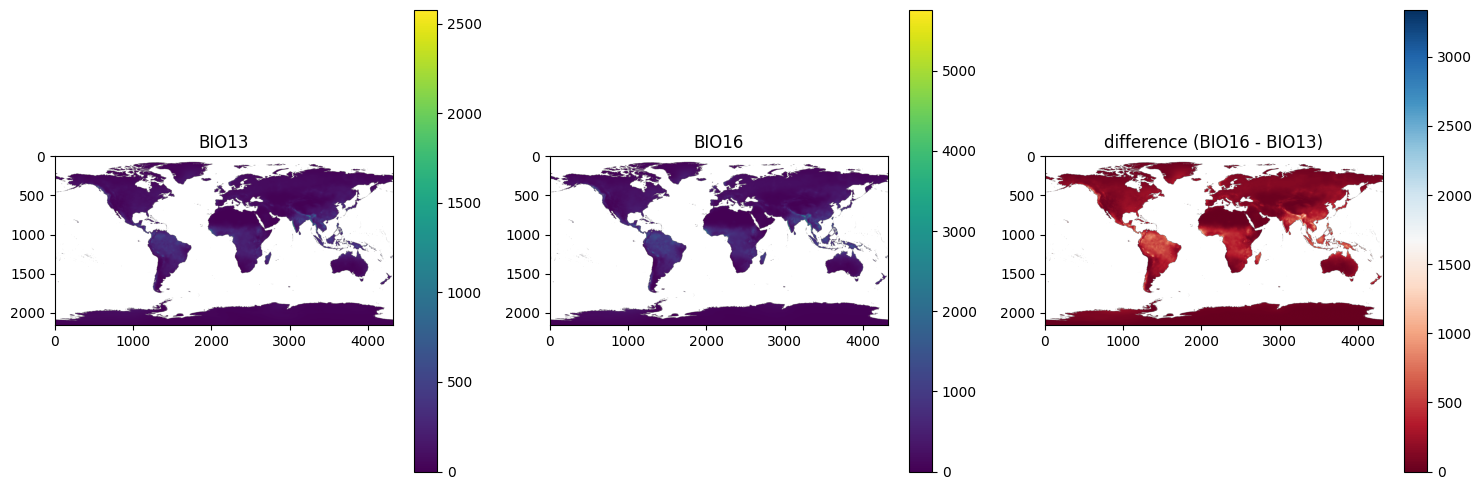

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio


var1 = "BIO13"   # precipitation of wettest month
var2 = "BIO16"   # precipitation of wettest quarter


src1 = rasterio.open(rasters[var1])
src2 = rasterio.open(rasters[var2])


array1 = src1.read(1)
mask1 = src1.read_masks(1)
array2 = src2.read(1)
mask2 = src2.read_masks(1)


array1 = np.ma.masked_where(~mask1, array1)
array2 = np.ma.masked_where(~mask2, array2)


diff = array2 - array1


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im1 = axes[0].imshow(array1, cmap='viridis')
axes[0].set_title(var1)
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(array2, cmap='viridis')
axes[1].set_title(var2)
plt.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(diff, cmap='RdBu')
axes[2].set_title('difference (BIO16 - BIO13)')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

### 3.1 Extract covariate values at site locations

Next, we extract covariate values from each raster at each site coordinate.

In [13]:
def extract_values_from_raster(raster_path, positions):
    dataset = rasterio.open(raster_path)
    return np.array(
        [val[0] for val in dataset.sample(positions, indexes=1, masked=True)]
    )

In [14]:
from tqdm import tqdm

coordinates = locations[["lon", "lat"]].to_numpy()
covariates = pd.DataFrame(
    {
        var_name: extract_values_from_raster(raster_path, coordinates)
        for var_name, raster_path in tqdm(rasters.items())
    },
    index=locations["site_id"],
)

covariates

  0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_1955/2229062056.py:3: UserWarning: Warning: converting a masked element to nan.
  return np.array(
100%|██████████| 20/20 [00:34<00:00,  1.75s/it]


,BIO01,BIO02,BIO03,BIO04,BIO05,BIO06,BIO07,BIO08,BIO09,BIO10,BIO11,BIO12,BIO13,BIO14,BIO15,BIO16,BIO17,BIO18,BIO19,ELEV
site_id,,,,,,,,,,,,,,,,,,,,
0,3.080167,12.711166,30.477297,1035.021851,24.167000,-17.540001,41.707001,13.074000,-2.440667,15.594833,-9.648500,412.0,78.0,19.0,50.010517,174.0,62.0,160.0,64.0,1166.0
1,10.941792,12.592750,67.786774,169.920410,19.610001,1.033000,18.577000,12.200833,8.601500,12.699834,8.601500,896.0,155.0,15.0,77.480911,446.0,51.0,272.0,51.0,2886.0
2,13.899792,16.521250,58.928699,395.790253,27.715000,-0.321000,28.035999,17.556833,11.694500,18.451834,8.808000,622.0,153.0,7.0,106.706703,420.0,24.0,371.0,54.0,2293.0
3,21.514875,14.317250,66.400375,182.114273,32.387001,10.825000,21.562000,22.283501,20.406666,23.841499,19.264334,1125.0,237.0,5.0,107.633957,683.0,22.0,332.0,31.0,1453.0
4,21.357082,19.102333,59.014286,489.395233,36.216000,3.847000,32.368999,25.632334,19.553333,26.605000,14.888833,326.0,74.0,3.0,96.327026,201.0,12.0,135.0,23.0,1248.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6328,12.823083,11.997000,30.081993,1016.667969,32.290001,-7.591000,39.881001,22.731501,-0.255167,24.999832,-0.255167,1001.0,140.0,30.0,44.371025,374.0,103.0,334.0,103.0,258.0
6329,10.952125,15.625251,36.367393,1010.198547,33.018002,-9.947000,42.965000,20.874001,-1.328333,23.570667,-1.328333,550.0,89.0,12.0,61.957397,258.0,39.0,233.0,39.0,812.0
6330,17.382334,12.694667,35.618156,840.171753,34.826000,-0.815000,35.640999,21.527666,6.778667,27.558334,6.778667,997.0,142.0,49.0,33.521431,339.0,173.0,219.0,173.0,231.0


Some sites fall on masked pixels (for example, outside valid land areas).
We'll remove those sites, because missing predictor values can break the models below.

In [15]:
covariates = covariates.dropna()
locations = locations[locations.index.isin(covariates.index)]
observations = observations[observations.site_id.isin(covariates.index)]
occ_matrix = occ_matrix[occ_matrix.index.isin(covariates.index)]

For convenience, let's combine observations and environmental variables into a single dataframe.

In [16]:
merged = pd.merge(
    left=observations,
    right=covariates,
    left_on="site_id",
    right_index=True,
)

`merged` now contains one row per observation, with both species and environmental covariates.

## 4. Ecological niche visualisation

Before fitting predictive models, let's look at the niche of a single species in geographic and environmental space.
In simple terms, a niche is the range of environmental conditions in which a species can persist.
With occurrence data, we usually visualise the realised niche (where the species is actually observed).
This helps us build ecological intuition before moving to model fitting.

In [17]:
species = "Scalopus_aquaticus"

Try changing `species` and re-running this section.
You should see that some species occupy broad climatic space, while others are more restricted.

First let's see the geographic range at which we find the selected species.

(14.541996, 79.980922)

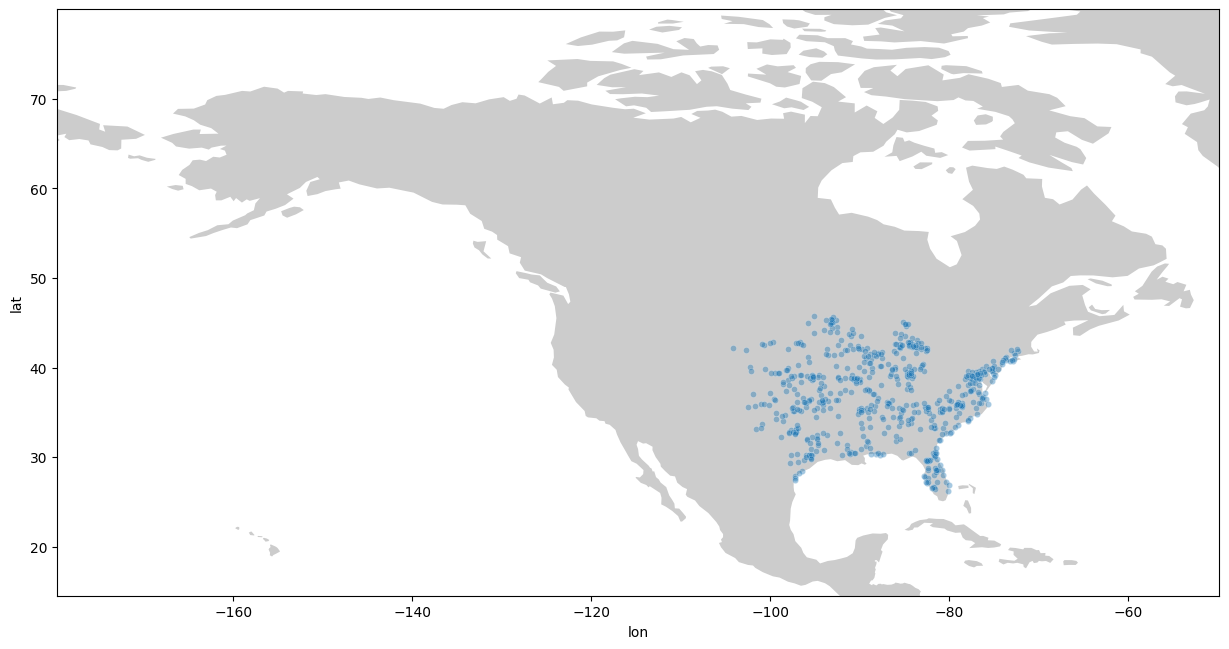

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(15, 10))
world.plot(ax=ax, alpha=0.4, color="grey")
sns.scatterplot(
    data=observations.query(f"species == '{species}'"),
    ax=ax,
    x="lon",
    y="lat",
    s=20,
    alpha=0.4,
)
ax.set_xlim(locations.lon.min(), locations.lon.max())
ax.set_ylim(locations.lat.min(), locations.lat.max())

Now inspect the range of environmental conditions where the species is observed.

In [19]:
is_in_site = occ_matrix[species]
species_covs = covariates[is_in_site]

species_covs.describe()

,BIO01,BIO02,BIO03,BIO04,BIO05,BIO06,BIO07,BIO08,BIO09,BIO10,BIO11,BIO12,BIO13,BIO14,BIO15,BIO16,BIO17,BIO18,BIO19,ELEV
count,595.000000,595.000000,595.000000,595.000000,595.000000,595.000000,595.000000,595.000000,595.000000,595.000000,595.000000,595.000000,595.000000,595.000000,595.000000,595.000000,595.000000,595.000000,595.000000,595.000000
mean,13.895545,12.053190,34.799642,862.885161,31.296166,-3.999729,35.295895,20.003763,6.581166,24.231255,2.909079,1073.900840,127.040336,55.398319,27.721942,348.010084,190.284034,315.436975,212.025210,221.465546
std,4.093255,1.332645,5.792044,172.562857,2.183760,6.234280,5.211850,5.220982,9.728024,2.373892,6.188445,249.339238,30.663401,24.099981,15.382268,82.327055,76.961762,84.617662,101.170811,201.716490
min,5.878875,7.117262,22.747774,341.822540,23.911364,-18.233999,18.419998,1.543667,-10.241667,18.012667,-10.241667,351.000000,65.000000,8.000000,5.928453,169.000000,26.000000,133.000000,26.000000,-1.000000
25%,11.077896,11.346254,30.352180,764.068146,29.621500,-8.120500,32.685001,18.156667,-1.224083,22.451501,-1.285833,907.500000,106.000000,36.500000,15.772204,298.000000,137.000000,271.000000,138.500000,74.500000
50%,13.364834,12.044499,34.004269,880.419434,31.607000,-4.370000,35.424999,20.866333,3.057333,24.402332,2.576833,1085.000000,118.000000,59.000000,22.006895,325.000000,200.000000,299.000000,212.000000,194.000000
75%,16.423062,12.783792,38.563280,989.660034,32.846502,-0.459500,38.500000,23.000250,16.089141,26.214334,6.402758,1238.000000,140.000000,75.000000,37.612915,374.000000,250.000000,325.500000,274.000000,285.000000
max,24.182291,17.317583,55.109753,1243.193359,36.477001,14.380000,46.170002,28.015833,27.168333,28.670666,19.787834,1932.000000,236.000000,134.000000,70.809158,678.000000,436.000000,638.000000,498.000000,1305.000000


We can inspect the species niche in a 2D environmental space.
You can change `x_axis` and `y_axis` to compare different covariate pairs.

The cloud of points represents the **realised niche** in the chosen environmental space.

<Axes: xlabel='BIO01', ylabel='BIO02'>

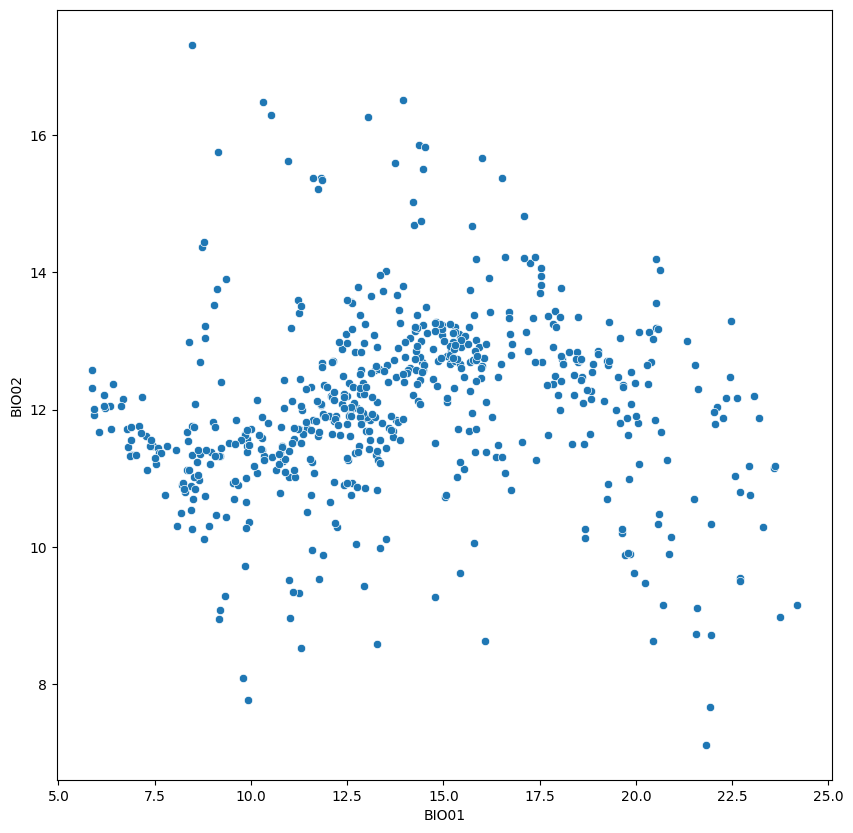

In [20]:
x_axis = "BIO01"
y_axis = "BIO02"

_, ax = plt.subplots(figsize=(10, 10))
sns.scatterplot(data=species_covs, x=x_axis, y=y_axis, ax=ax)
ax

One way to visualise the occupied niche is to draw a convex hull around the presence points.

Note: this is a geometric summary, not a true biological boundary.
It is easy to compute and useful for visual comparison, but can be sensitive to outliers.

<Axes: xlabel='BIO01', ylabel='BIO02'>

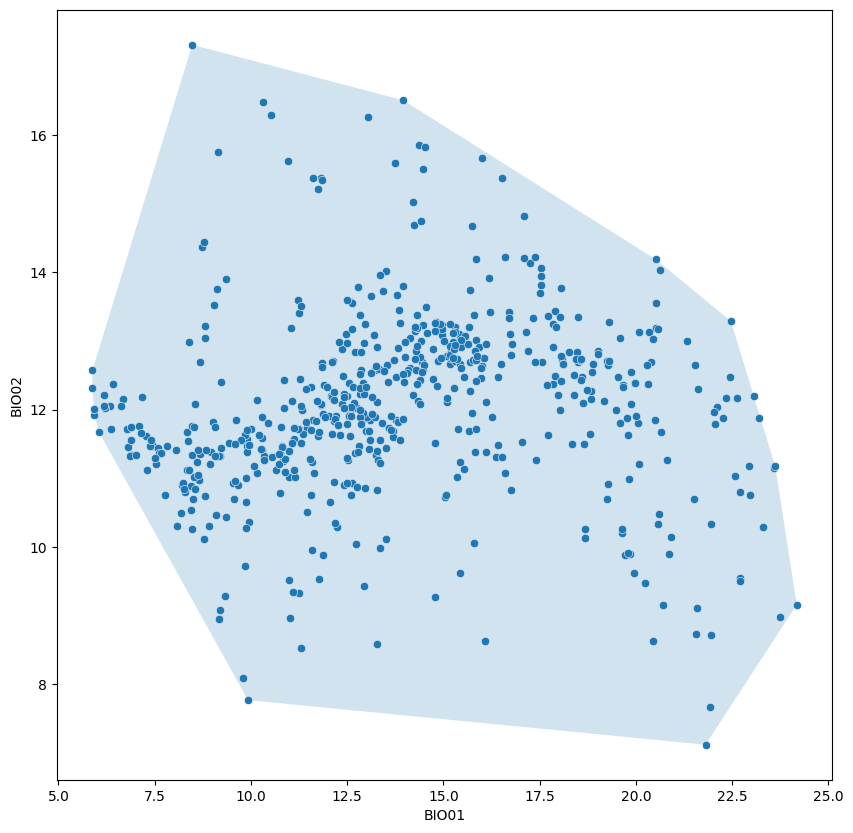

In [21]:
from matplotlib.patches import Polygon
from scipy.spatial import ConvexHull

hull = ConvexHull(species_covs[[x_axis, y_axis]].dropna())

_, ax = plt.subplots(figsize=(10, 10))
sns.scatterplot(data=species_covs, x=x_axis, y=y_axis, ax=ax)
polygon = Polygon(hull.points[hull.vertices], alpha=0.2)
ax.add_patch(polygon)
ax

Finally, compare occupied points against the environmental background, i.e. sites at which the species was not observed.
This shows whether the species occupies a small, distinct subset of available climate space, or a broad fraction of it.

<Axes: xlabel='BIO01', ylabel='BIO02'>

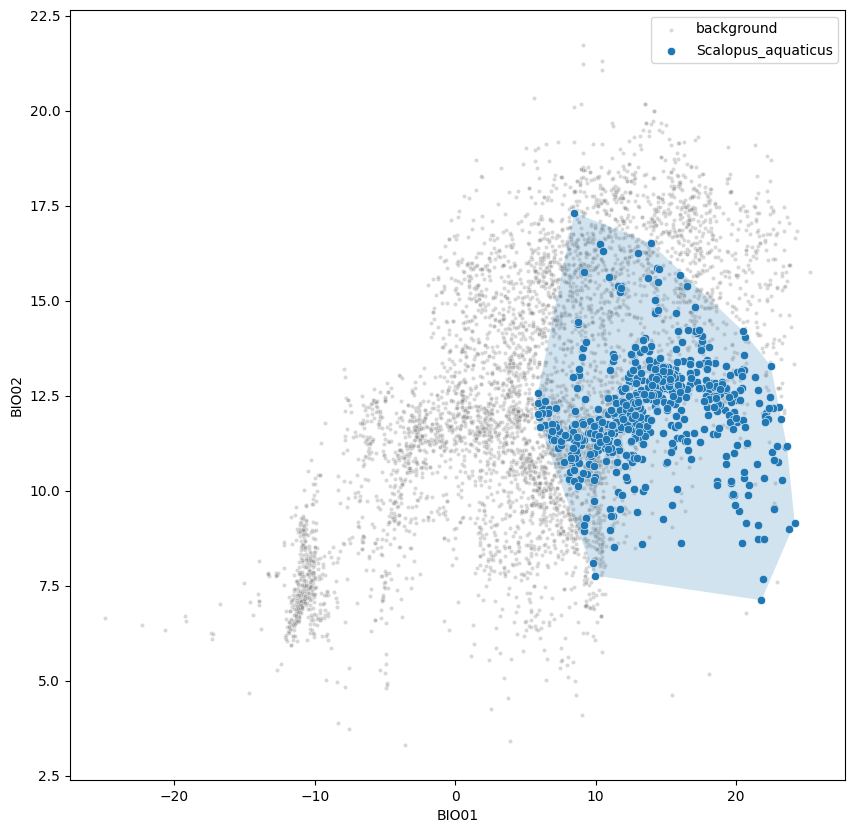

In [22]:
_, ax = plt.subplots(figsize=(10, 10))
sns.scatterplot(
    data=covariates[~is_in_site],
    x=x_axis,
    y=y_axis,
    ax=ax,
    color="gray",
    alpha=0.3,
    marker=".",
    label="background",
)
sns.scatterplot(data=species_covs, x=x_axis, y=y_axis, ax=ax, label=species)
polygon = Polygon(hull.points[hull.vertices], alpha=0.2)
ax.add_patch(polygon)
ax

### 4.1 Compare niches across all species

We can also visualise niches across all species at the same time.
Instead of manually choosing two BIO variables, we use PCA and keep the first two components (those explaining most variance).
This helps us see whether species occupy distinct or overlapping parts of environmental space.

Remember that PCA axes are linear combinations of the original covariates.
They are useful for visual structure, but less directly interpretable ecologically than the original BIO variables.

In [23]:
from sklearn.preprocessing import StandardScaler

feature_names = list(rasters.keys())

scaled_features = StandardScaler().fit_transform(covariates)

<Axes: xlabel='PCA1', ylabel='PCA2'>

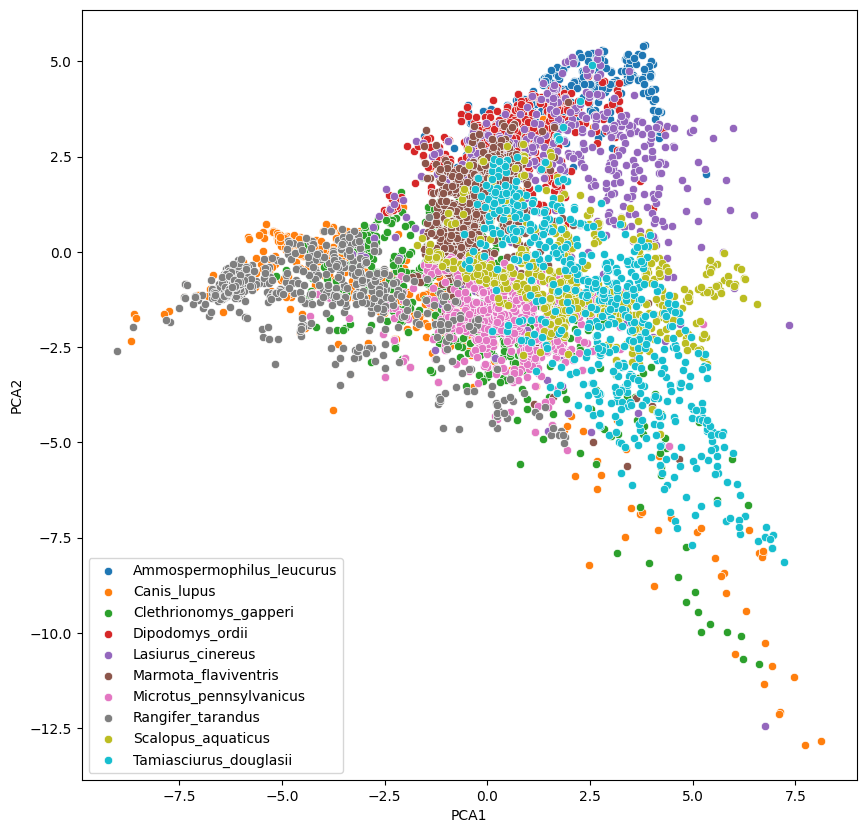

In [24]:
from sklearn.decomposition import PCA

X, Y = PCA(n_components=2).fit_transform(scaled_features).T

_, ax = plt.subplots(figsize=(10, 10))

for species in occ_matrix:
    sns.scatterplot(
        x=X[occ_matrix[species]],
        y=Y[occ_matrix[species]],
        label=species,
    )

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax

And also in three dimensions!

In [25]:
import plotly.express as px

scaled_features = StandardScaler().fit_transform(merged[feature_names])
X, Y, Z = PCA(n_components=3).fit_transform(scaled_features).T

fig = px.scatter_3d(x=X, y=Y, z=Z, color=merged["species"])
fig.show()

## 5. Species distribution modelling

Now let's frame species distribution mapping as a machine learning problem using the Task, Experience, and Performance framework.

- **Task (T):** predict whether a species is present at a site.
- **Experience (E):** observed presences/absences plus environmental covariates.
- **Performance (P):** use ROC-AUC on held-out data.

For this practical, we treat non-detections as absences.
That is a common simplification in SDM workflows, but imperfect detection can blur this distinction.

### Metrics

There are many ways to evaluate SDMs.
Here we focus on ROC-AUC.
ROC-AUC means **Area Under the Receiver Operating Characteristic curve**.

In plain terms, it asks:
if we pick one true presence and one true absence at random, how often does the model assign a higher score to the presence site?

To build the ROC curve, we sweep through many score thresholds and, at each threshold, compute:

- **true positive rate (TPR):** proportion of real presences correctly predicted as presence;
- **false positive rate (FPR):** proportion of real absences incorrectly predicted as presence.

The ROC curve plots FPR (x-axis) against TPR (y-axis).
The AUC then summarises that curve into one number:

- `0.5` means random ranking,
- `1.0` means perfect ranking,
- values below `0.5` usually indicate that predictions are effectively reversed.

Here's a function that we can use to evaluate any prediction.

In [26]:
from sklearn import metrics


def evaluate_species_prediction(is_present, predicted_score):
    roc_auc = metrics.roc_auc_score(is_present, predicted_score)
    display = metrics.RocCurveDisplay.from_predictions(is_present, predicted_score)
    display.ax_.set_title(f"ROC curve (AUC = {roc_auc:.3f})")
    return display

As a sanity check, let's evaluate a random predictor.
Its ROC curve should be close to the diagonal and its AUC close to 0.5.

This gives us a minimum baseline for comparison.
In the next step, we switch to held-out evaluation for fairer model comparison.

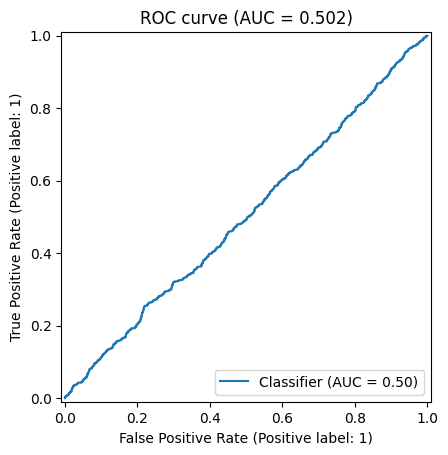

In [27]:
species = "Canis_lupus"

is_present = occ_matrix[species]
random_predictions = np.random.random(len(is_present))

evaluate_species_prediction(is_present, random_predictions)

#### 🖌️ _Evaluate simple baselines_

Another very simple benchmark is a model that always predicts the species as present, or always predicts the species as absent.

Use the `evaluate_species_prediction` function above to compute the ROC-AUC for both.

In [69]:
species = "Canis_lupus"   # 替换为你选择的物种
y_true = occ_matrix[species].astype(int).values

# 1. 始终预测存在
y_pred_always_present = np.ones_like(y_true)
auc_present = evaluate_species_prediction(y_true, y_pred_always_present)

# 2. 始终预测不存在
y_pred_always_absent = np.zeros_like(y_true)
auc_absent = evaluate_species_prediction(y_true, y_pred_always_absent)

print(f"ROC-AUC (always present): {auc_present:.3f}")
print(f"ROC-AUC (always absent): {auc_absent:.3f}")

ROC-AUC (always present): 0.500
ROC-AUC (always absent): 0.500


### Held-out data

To make a fair assessment, we need to evaluate on data not used for fitting.
So we split data into training and test sets.

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    covariates,
    occ_matrix,
    test_size=0.3,
    random_state=42,
)

#### 🖌️ _Splitting strategies_

With spatial data, random train/test splits can be optimistic, because nearby points tend to be environmentally similar.

What other strategies do you think could be useful to design a better split?
Think about approaches that reduce spatial or environmental leakage between train and test data.

### Prediction visualisation

Besides summary metrics, we can map model predictions in geographic space.
This gives a more complete view of model behaviour than a single scalar metric.

These maps are often interpreted as **habitat suitability** surfaces.

To ease map prediction, we load all covariate layers and stack them into one array.

In [29]:
stack = []

for path in rasters.values():
    src = rasterio.open(path)
    array = src.read(1)
    mask = src.read_masks(1)
    src.close()
    stack.append(np.ma.masked_where(~mask, array))

stack = np.ma.stack(stack)

Below are helper functions we will reuse for map prediction and plotting.
You do not need to understand every line at this stage.

In [30]:
def get_non_masked_features(stack):
    X, Y = np.where(~stack.mask.any(axis=0))
    return stack[:, X, Y].T.filled()


def assemble_into_map(predictions, stack=stack):
    mask = ~stack.mask.any(axis=0)
    X, Y = np.where(mask)
    result = np.zeros_like(mask, dtype=np.float32)
    result[X, Y] = predictions
    return np.ma.masked_where(~mask, result)


def plot_predicted_species_map(
    predicted_scores,
    species,
    stack=stack,
    min_lat=None,
    min_lon=None,
    max_lat=None,
    max_lon=None,
):
    _, ax = plt.subplots(figsize=(15, 10))

    map_array = assemble_into_map(predicted_scores, stack=stack)

    # Show the map of scores
    m = ax.imshow(map_array, cmap="inferno", extent=(-180, 180, -90, 90))

    # Add locations in the train dataset where the species appears
    train_locations = y_train.index[y_train[species]]
    sns.scatterplot(
        data=locations.iloc[train_locations],
        x="lon",
        y="lat",
        label="train",
    )

    # Add locations in the test dataset where the species appears
    test_locations = y_test.index[y_test[species]]
    sns.scatterplot(
        data=locations.iloc[test_locations],
        x="lon",
        y="lat",
        label="test",
    )

    # Add colorbar
    plt.colorbar(m, ax=ax)

    # Add species name to title
    ax.set_title(species)

    # Constrain the lat/lon
    if min_lat is None:
        min_lat = locations.lat.min()

    if max_lat is None:
        max_lat = locations.lat.max()

    if min_lon is None:
        min_lon = locations.lon.min()

    if max_lon is None:
        max_lon = locations.lon.max()

    ax.set_xlim(min_lon, max_lon)
    ax.set_ylim(min_lat, max_lat)

    return ax

### 5.1 Random forest baseline

A common SDM baseline is a supervised classifier trained on site-level covariates.
Here we use a random forest to learn the relationship between covariates and species presence.

Random forests can capture non-linear responses and interactions, which are common in ecological systems.
They also tend to work well without heavy parameter tuning, which makes them a strong baseline.

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

In [32]:
rf_model.fit(X_train, y_train[species])

RandomForestClassifier()

Now evaluate predictions on the held-out test set.

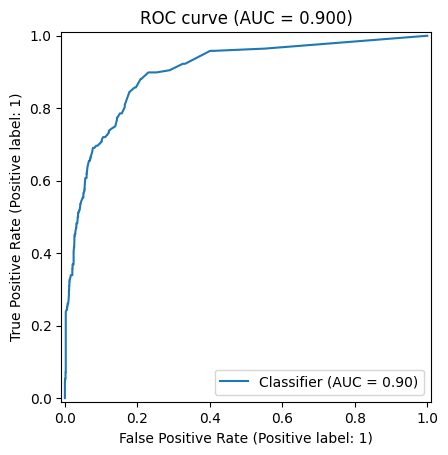

In [33]:
y_scores = rf_model.predict_proba(X_test)[:, 1]

evaluate_species_prediction(y_test[species], y_scores)

Then project predictions across all valid raster cells to produce a suitability map.

When interpreting the map, look for broad gradients and plausible range structure, and compare visually with known occurrences.

In [34]:
map_features = get_non_masked_features(stack)

rf_map_preds = rf_model.predict_proba(map_features)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names



<Axes: title={'center': 'Canis_lupus'}, xlabel='lon', ylabel='lat'>

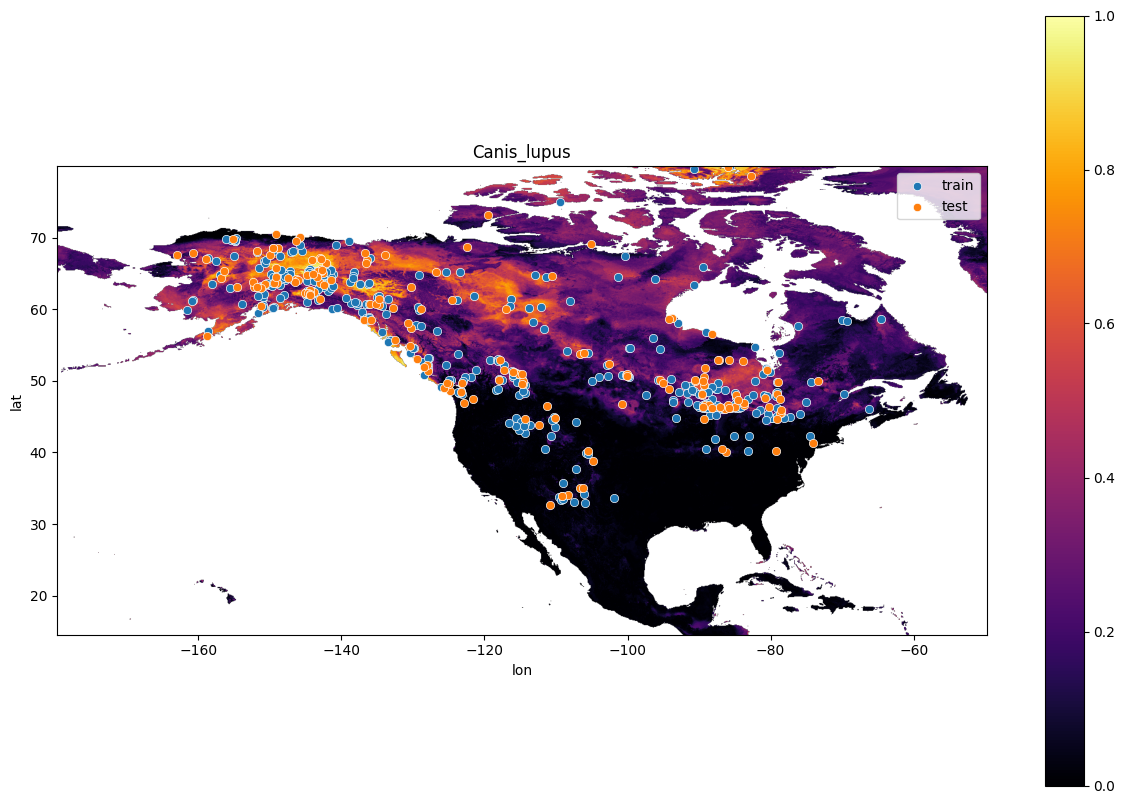

In [35]:
plot_predicted_species_map(rf_map_preds, species)

#### 🖌️ _Random Forest extrapolation_

Right now the plot is zoomed to North America, but predictions were generated for all valid raster cells globally.

Look at the `plot_predicted_species_map` function definition and figure out how to display the whole world.
How do predictions look outside North America, and do they make biological sense for your focal species?

### 5.2 Kernel density niche model

Another approach is to model the environmental niche directly.
We can fit a density estimator (`KernelDensity`) to presence sites in covariate space, and then score how similar each location is to that niche.

This is conceptually close to classic environmental-envelope approaches in biogeography.
Unlike random forests, this method focuses explicitly on the distribution of environments where the species is observed.

In [36]:
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler

kd_model = KernelDensity(
    bandwidth=0.04,
    kernel="gaussian",
    algorithm="ball_tree",
)

In [37]:
# Because the covariates are recorded in different units
# it's a good idea to standardise them.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)

# Fit the model using only the covariates in the train set
# and where the species occurs
kd_model.fit(X_train_s[y_train[species]])

KernelDensity(algorithm='ball_tree', bandwidth=0.04)

`KernelDensity` returns log-density values.
For easier visual comparison with other models, we map scores to a 0-1 range with a sigmoid transform.

In [38]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

/tmp/ipykernel_1955/3196251242.py:2: RuntimeWarning:

overflow encountered in exp



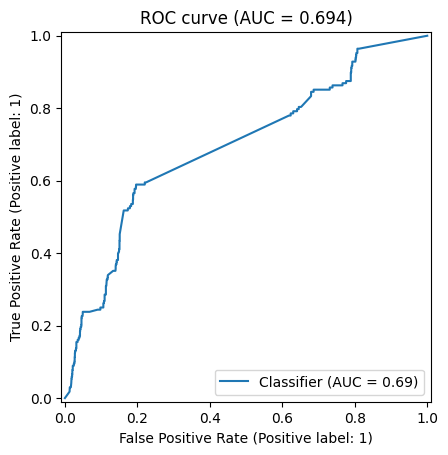

In [39]:
X_test_s = scaler.transform(X_test)

y_scores = sigmoid(kd_model.score_samples(X_test_s))

evaluate_species_prediction(y_test[species], y_scores)

Now let's use it to predict across the globe.

In [40]:
map_features = get_non_masked_features(stack)

map_features_s = scaler.transform(map_features)

kd_map_preds = sigmoid(kd_model.score_samples(map_features_s))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

/tmp/ipykernel_1955/3196251242.py:2: RuntimeWarning:

overflow encountered in exp



And finally see the map of predictions.

<Axes: title={'center': 'Canis_lupus'}, xlabel='lon', ylabel='lat'>

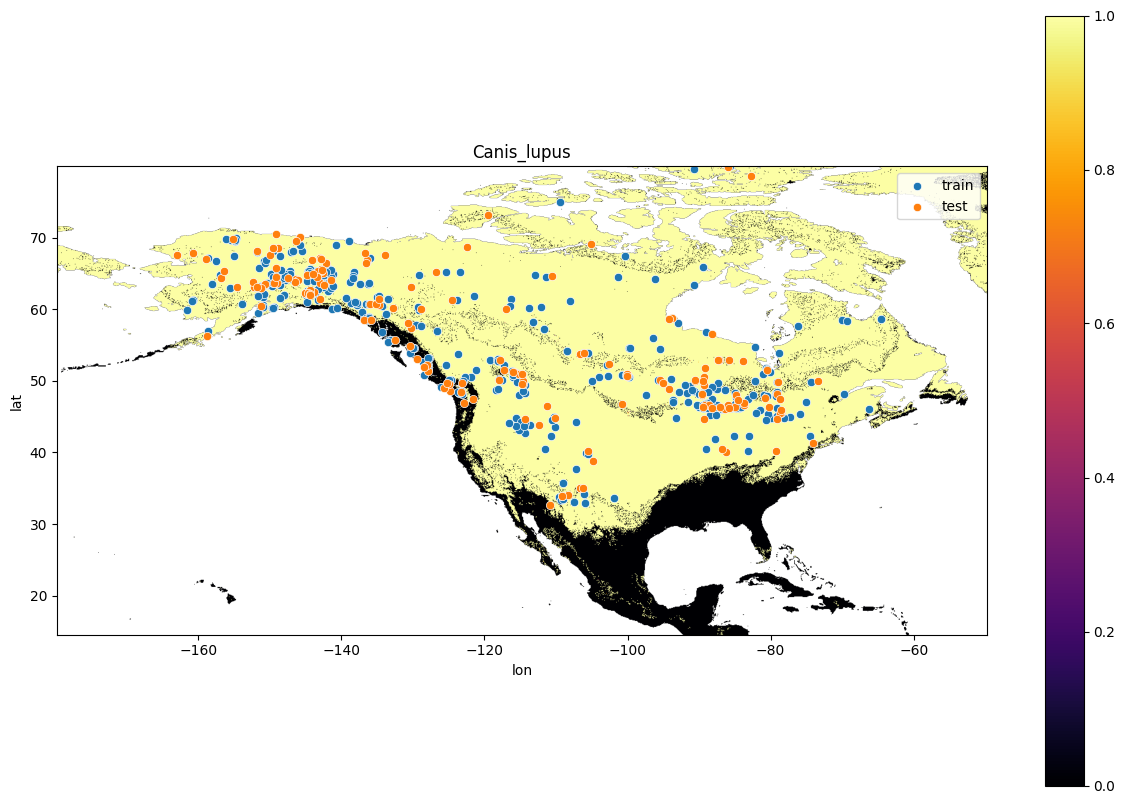

In [41]:
plot_predicted_species_map(kd_map_preds, species)

## 6. Neural networks

Species distribution models can also be trained with neural networks.
Instead of fitting one model per species, we can train a single multi-output model.
Training on multiple species at once can improve generalisation, because the model can share structure across species.

You can think of this as a simple form of multi-task learning:
each species is a separate prediction task, but they share a common hidden representation of environment.

### 6.1 Using covariates (multi-species model)

As in the Deep Learning practical, we will use Keras to train the model.

The output layer has one sigmoid unit per species, and we use binary cross-entropy loss.

In [42]:
import keras
from keras import layers
from sklearn.preprocessing import StandardScaler

keras.utils.set_random_seed(42)

nn_scaler = StandardScaler()

X_train_nn = nn_scaler.fit_transform(X_train).astype("float32")
X_test_nn = nn_scaler.transform(X_test).astype("float32")

species_names = list(y_train.columns)
y_train_nn = y_train[species_names].astype("float32").to_numpy()
y_test_nn = y_test[species_names].astype("float32").to_numpy()

Build a simple multilayer neural network with one output per species.

In [43]:
nn_model = keras.Sequential(
    [
        layers.Input(shape=(X_train_nn.shape[1],)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(len(species_names), activation="sigmoid"),
    ]
)

nn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(name="roc_auc", curve="ROC")],
)

nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,594 (45.29 KB)

 Trainable params: 11,594 (45.29 KB)

 Non-trainable params: 0 (0.00 B)

Now train for up to 200 epochs.
Because models can start overfitting, we use early stopping to halt training when validation performance has not improved for 20 epochs.

In [44]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=20,
    restore_best_weights=True,
)

history = nn_model.fit(
    X_train_nn,
    y_train_nn,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=[early_stop],
)

Epoch 1/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3991 - roc_auc: 0.6835 - val_loss: 0.2275 - val_roc_auc: 0.8923
Epoch 2/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2211 - roc_auc: 0.8911 - val_loss: 0.1851 - val_roc_auc: 0.9351
Epoch 3/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1978 - roc_auc: 0.9183 - val_loss: 0.1735 - val_roc_auc: 0.9428
Epoch 4/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1894 - roc_auc: 0.9263 - val_loss: 0.1682 - val_roc_auc: 0.9458
Epoch 5/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1833 - roc_auc: 0.9322 - val_loss: 0.1651 - val_roc_auc: 0.9480
Epoch 6/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1783 - roc_auc: 0.9366 - val_loss: 0.1627 - val_roc_auc: 0.9492
Epoch 7/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1743 - roc_auc: 0.9393 - val_loss: 0.1608 - val_roc_auc: 0.9506
Epoch 8/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1732 - roc_auc: 0.9406 - val_loss: 0.1595 - val_roc_auc: 0.9513

Let's see the training history.

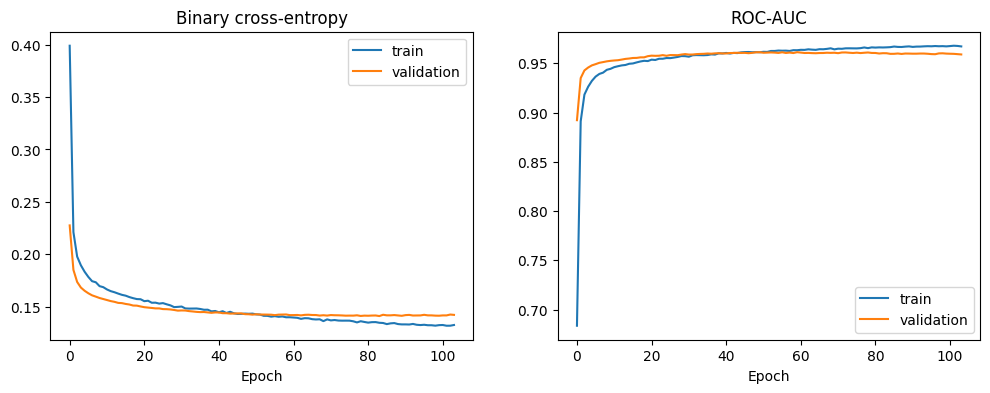

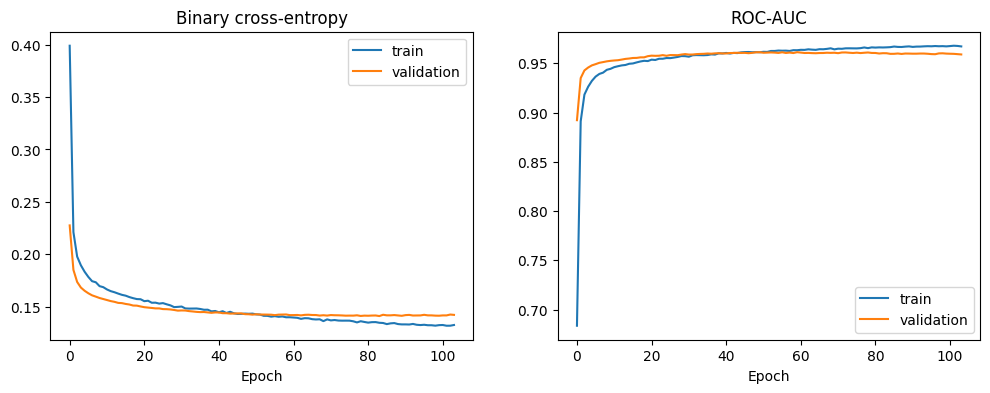

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"], label="train")
ax1.plot(history.history["val_loss"], label="validation")
ax1.set_title("Binary cross-entropy")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(history.history["roc_auc"], label="train")
ax2.plot(history.history["val_roc_auc"], label="validation")
ax2.set_title("ROC-AUC")
ax2.set_xlabel("Epoch")
ax2.legend()

fig

Now evaluate predictions for a focal species, and then inspect ROC curves across all species.
This lets us check both species-specific performance and overall behaviour across our species pool.

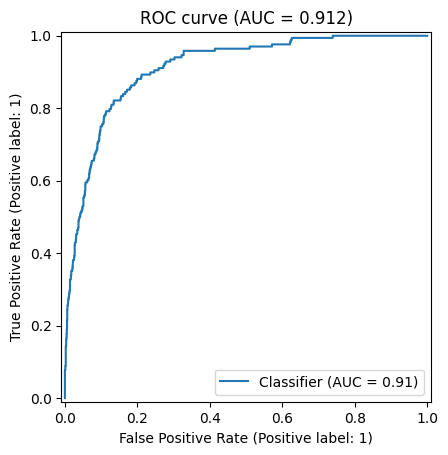

In [46]:
species = "Canis_lupus"

nn_scores_all = nn_model.predict(X_test_nn, verbose=0)
species_index = species_names.index(species)

evaluate_species_prediction(
    y_test_nn[:, species_index],
    nn_scores_all[:, species_index],
)

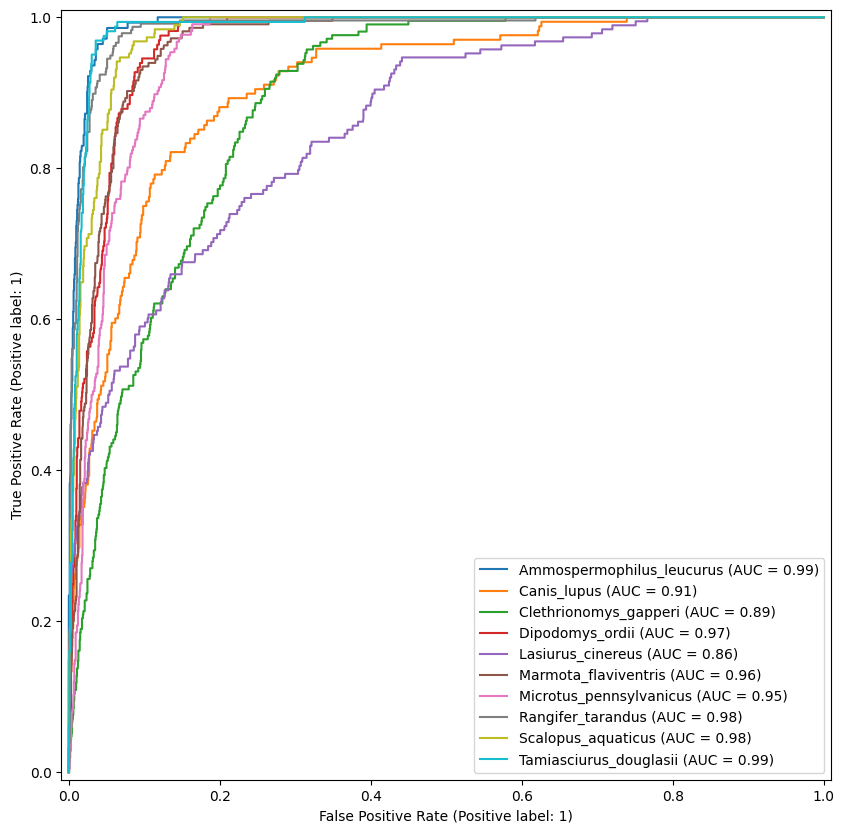

In [47]:
fig, ax = plt.subplots(figsize=(10, 10))

for index, species_name in enumerate(species_names):
    metrics.RocCurveDisplay.from_predictions(
        y_test_nn[:, index],
        nn_scores_all[:, index],
        ax=ax,
        name=species_name,
    )

We can run the model on the whole globe and get predictions for all species at once.
This step produces one map layer per species from the same multi-output model.

In [48]:
map_features = get_non_masked_features(stack)
map_features_nn = nn_scaler.transform(map_features).astype("float32")
nn_map_preds_all = nn_model.predict(map_features_nn, batch_size=256)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



12384/12384 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step


Now visualise predictions for one focal species.

<Axes: title={'center': 'Clethrionomys_gapperi'}, xlabel='lon', ylabel='lat'>

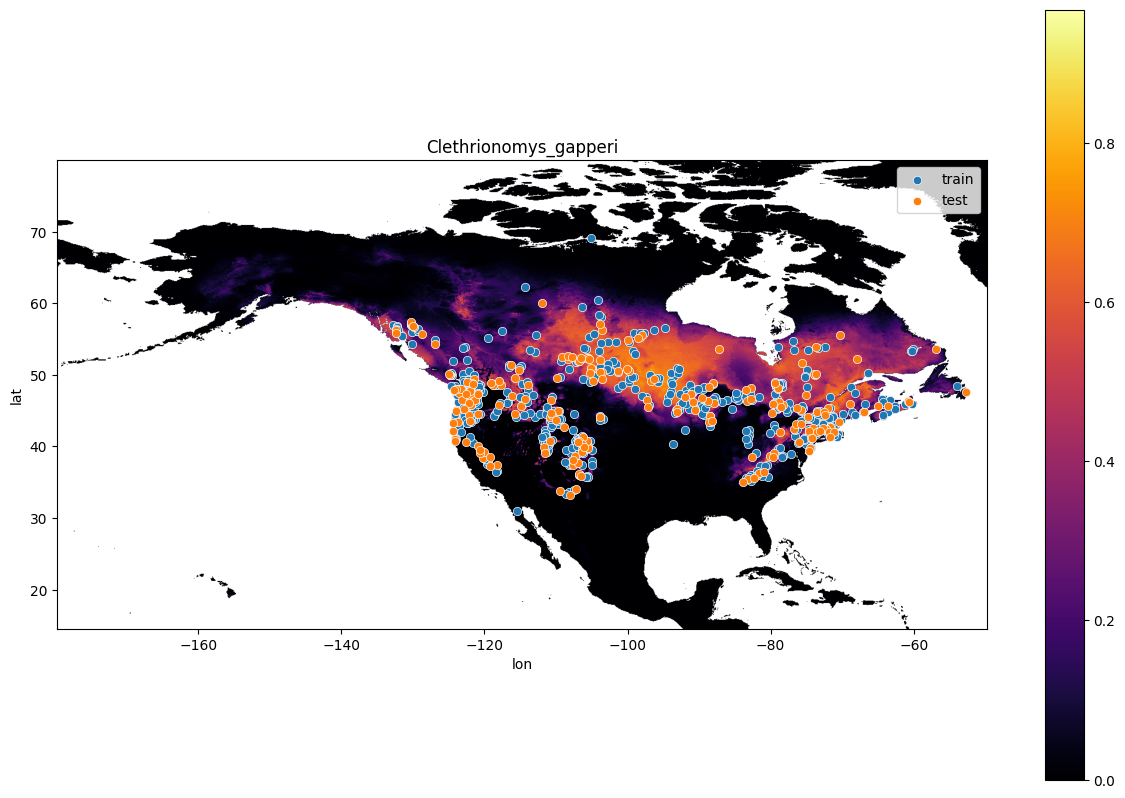

In [49]:
species = species_names[2]
species_index = species_names.index(species)

plot_predicted_species_map(nn_map_preds_all[:, species_index], species)

### 6.2 Using location only

As a comparison, we can train a second neural network that only uses longitude and latitude as input features.

This model does not see any environmental covariates.
If it performs well, it suggests there is strong spatial structure in the training data that can already explain part of species distributions.

In practice, this may reflect real biogeographic structure, but it can also absorb sampling bias and spatial autocorrelation.

This connects to recent work on spatial implicit neural representations.

> Cole, E., Van Horn, G., Lange, C., Shepard, A., Leary, P., Perona, P., ... & Mac Aodha, O. (2023, July). Spatial implicit neural representations for global-scale species mapping. In International conference on machine learning (pp. 6320-6342). PMLR.

In [50]:
locations = (
    observations[["lon", "lat"]]
    .drop_duplicates()
    .reset_index()
    .rename(columns={"index": "site_id"})
)

site_coordinates = locations.set_index("site_id")[["lon", "lat"]]

X_train_xy = site_coordinates.loc[X_train.index].to_numpy().astype("float32")
X_test_xy = site_coordinates.loc[X_test.index].to_numpy().astype("float32")

species_names = list(y_train.columns)
y_train_xy = y_train[species_names].astype("float32").to_numpy()
y_test_xy = y_test[species_names].astype("float32").to_numpy()

xy_scaler = StandardScaler()
X_train_xy = xy_scaler.fit_transform(X_train_xy).astype("float32")
X_test_xy = xy_scaler.transform(X_test_xy).astype("float32")

Let's use the same model architecture, but now as inputs we have only two variables (lat/lon).

In [51]:
loc_model = keras.Sequential(
    [
        layers.Input(shape=(2,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(len(species_names), activation="sigmoid"),
    ]
)

loc_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(name="roc_auc", curve="ROC")],
)

loc_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,290 (36.29 KB)

 Trainable params: 9,290 (36.29 KB)

 Non-trainable params: 0 (0.00 B)

Training is also the same.

In [52]:
early_stop_loc = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=20,
    restore_best_weights=True,
)

history_loc = loc_model.fit(
    X_train_xy,
    y_train_xy,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=[early_stop_loc],
)

Epoch 1/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.5606 - roc_auc: 0.5786 - val_loss: 0.3508 - val_roc_auc: 0.6758
Epoch 2/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3057 - roc_auc: 0.7062 - val_loss: 0.2662 - val_roc_auc: 0.8253
Epoch 3/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2660 - roc_auc: 0.8185 - val_loss: 0.2391 - val_roc_auc: 0.8793
Epoch 4/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2452 - roc_auc: 0.8588 - val_loss: 0.2242 - val_roc_auc: 0.8975
Epoch 5/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2348 - roc_auc: 0.8753 - val_loss: 0.2160 - val_roc_auc: 0.9055
Epoch 6/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2283 - roc_auc: 0.8831 - val_loss: 0.2108 - val_roc_auc: 0.9090
Epoch 7/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2227 - roc_auc: 0.8898 - val_loss: 0.2072 - val_roc_auc: 0.9120
Epoch 8/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2191 - roc_auc: 0.8941 - val_loss: 0.2039 - val_roc_auc: 0.9157

Are the training curves any different? And how good does the model get?

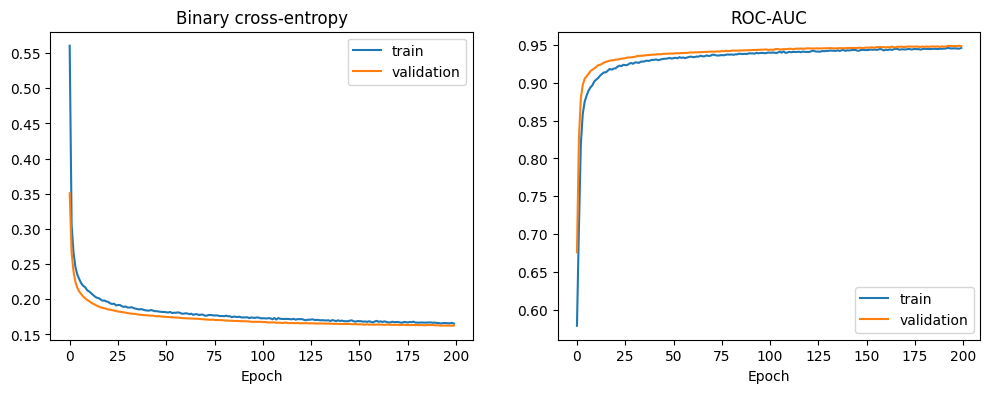

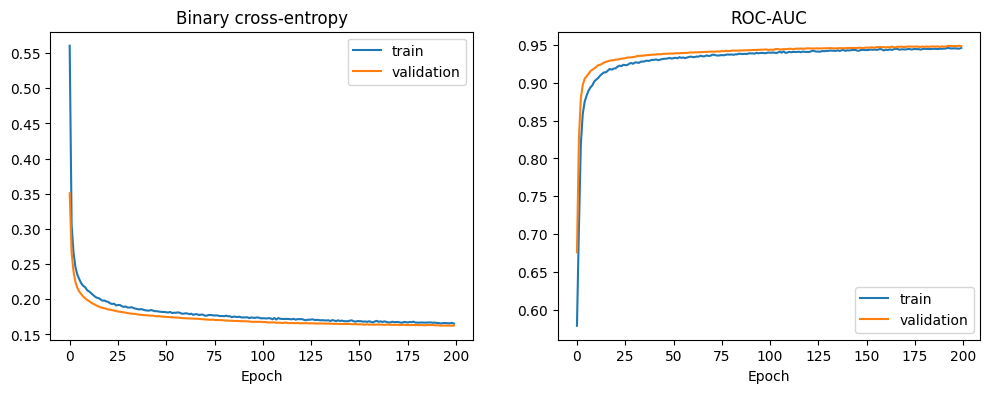

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_loc.history["loss"], label="train")
ax1.plot(history_loc.history["val_loss"], label="validation")
ax1.set_title("Binary cross-entropy")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(history_loc.history["roc_auc"], label="train")
ax2.plot(history_loc.history["val_roc_auc"], label="validation")
ax2.set_title("ROC-AUC")
ax2.set_xlabel("Epoch")
ax2.legend()

fig

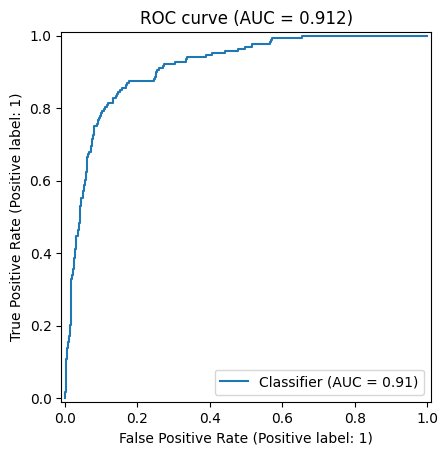

In [54]:
species = "Canis_lupus"

loc_scores_all = loc_model.predict(X_test_xy, verbose=0)
species_index = species_names.index(species)

evaluate_species_prediction(
    y_test_xy[:, species_index],
    loc_scores_all[:, species_index],
)

<Axes: xlabel='False Positive Rate (Positive label: 1)', ylabel='True Positive Rate (Positive label: 1)'>

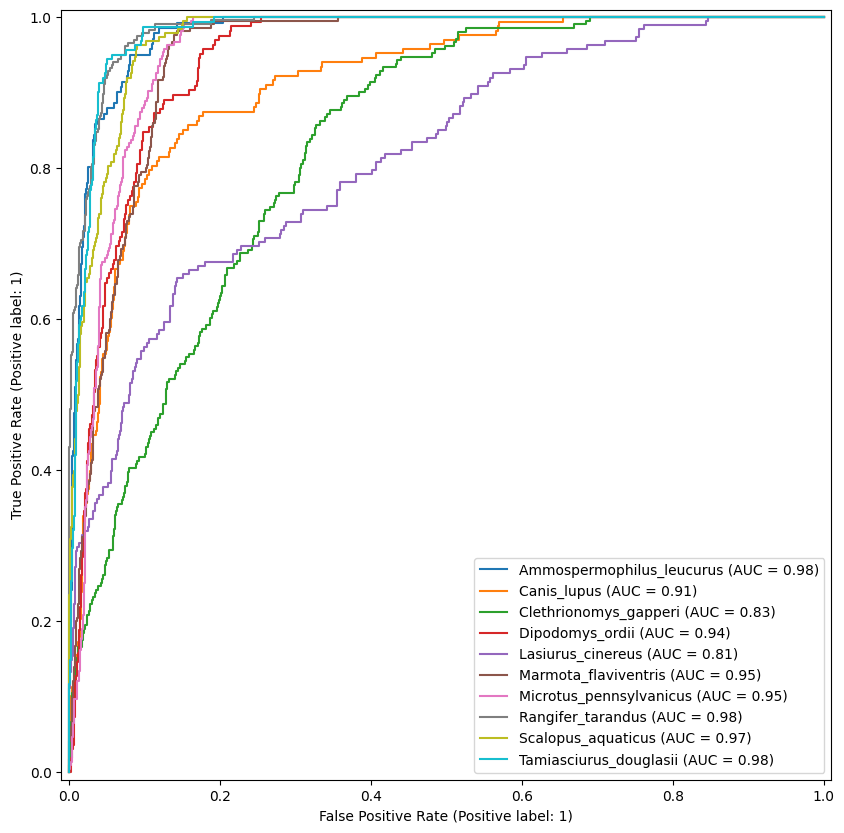

In [55]:
fig, ax = plt.subplots(figsize=(10, 10))

for index, species_name in enumerate(species_names):
    y_true = y_test_xy[:, index]

    if np.unique(y_true).size < 2:
        continue

    metrics.RocCurveDisplay.from_predictions(
        y_true,
        loc_scores_all[:, index],
        ax=ax,
        name=species_name,
    )

ax

To map the predictions, we need the lon/lat coordinates of all valid raster cells.

In [56]:
def get_non_masked_coordinates(stack, template_raster_path):
    with rasterio.open(template_raster_path) as src:
        transform = src.transform

    mask = ~stack.mask.any(axis=0)
    rows, cols = np.where(mask)
    xs, ys = rasterio.transform.xy(transform, rows, cols, offset="center")

    return np.column_stack([xs, ys]).astype("float32")

In [57]:
map_coordinates = get_non_masked_coordinates(stack, rasters["BIO01"])
map_coordinates_xy = xy_scaler.transform(map_coordinates).astype("float32")

loc_map_preds_all = loc_model.predict(map_coordinates_xy, batch_size=256)

12384/12384 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step


<Axes: title={'center': 'Ammospermophilus_leucurus'}, xlabel='lon', ylabel='lat'>

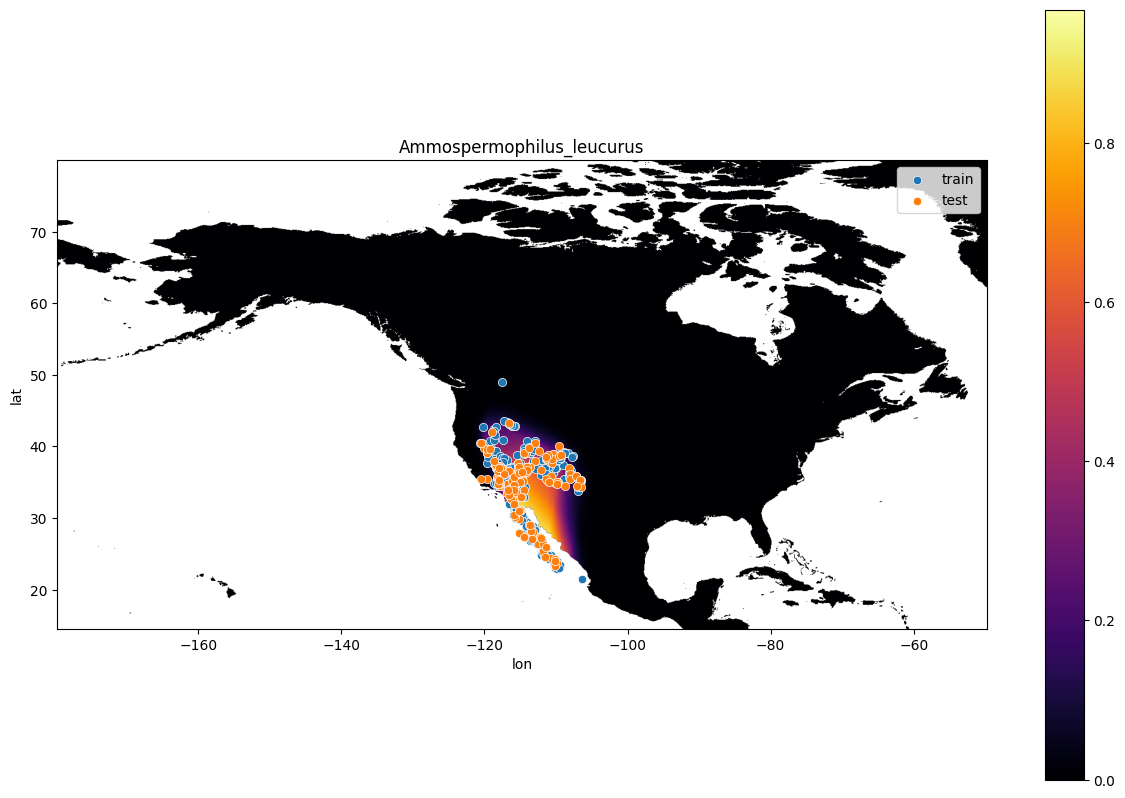

In [58]:
species = species_names[0]
species_index = species_names.index(species)

plot_predicted_species_map(loc_map_preds_all[:, species_index], species)

#### 🖌️ _What is the location-only model learning?_

Think about what this model is learning.
The hidden layers transform each coordinate pair into latent spatial features that are useful for prediction.
In practice, this means the model is learning correlations in where species have been observed.
How reliable would this model be for extrapolation to new regions or future climates?